# CALCULAR ENTROPIES DATASETS I AFEGIR A RESULTATS

In [1]:
#from comparative.entities import Dataset

from dataclasses import dataclass
from pathlib import Path

@dataclass
class Dataset:
    dataset_id: str # num o codi curt
    label: str # categoria
    description: str
    fasta_path: Path 
    size_bytes: int
    num_bases: int # només A,C,G,T
    base_counts: dict[str, int] # counts A,C,G,T,N i unknown
    size_header: float # quants caracters te el header
    entropy_acgtn_bits_per_base: float | None # Entropia H0 sobre A,C,G,T,N
    entropy_acgt_bits_per_base: float | None # Entropia H0 sobre A,C,G,T ignorant N
    entropy_seq_all_bits_per_base: float | None # Entropia H0 sobre la seqüència completa
    entropy_seq_all_headers_bits_per_base: float | None # Entropia H0 sobre la seqüència completa i els headers
    contains_n: bool = False

            

In [2]:
#from comparative.datasets import load_datasets

In [3]:
import os
from pathlib import Path
from typing import List, Optional
import sys
from pathlib import Path
# print working directory

sys.path.append(str(Path("..").resolve()))
from comparative.fasta_utils import count_header_symbols, count_fasta_symbols
from comparative.utils import shannon_entropy_from_counts, compute_dataset_entropies



In [4]:
DATA_DIR = "/home/helen/genomic_benchmark/DATA/data"

datasets = dict()
for fasta_path in sorted(Path(DATA_DIR).rglob("*")):
    if not fasta_path.is_file():
        continue
    print(f"Processing {fasta_path.stem}...")
    datasets[fasta_path.stem] = dict()
    datasets[fasta_path.stem]["category"] = fasta_path.parent.stem
    base_counts = count_fasta_symbols(fasta_path)
    entropies = compute_dataset_entropies(fasta_path, base_counts)
    datasets[fasta_path.stem]["base_counts"] = base_counts
    datasets[fasta_path.stem]["entropies"] = entropies



Processing bacillus_subtilis...
Processing escherichia_coli...
Processing mycobacterium_tuberculosis...
Processing pseudomonas_aeruginosa...
Processing salmonella_typhimurium...
Processing staphylococcus_aureus...
Processing homo_sapiens_chr1...
Processing homo_sapiens_chr21...
Processing homo_sapiens_chr22...
Processing homo_sapiens_chr4...
Processing homo_sapiens_chrX...
Processing homo_sapiens_chrY...
Processing arabidopsis_thaliana...
Processing candidozma_auris...
Processing saccharomyces_cerevisiae...
Processing yarrowia_lipolytica...
Processing PV559941.1...
Processing PV559966.1...
Processing PV559974.1...
Processing PV559982.1...
Processing PV560051.1...
Processing mitochondria...
Processing hiv...
Processing hpv16...
Processing hsv1...
Processing phage_lambda...
Processing phix174...
Processing sars_cov_2...


In [5]:
categories = set()
for dataset in datasets.values():
    categories.add(dataset["category"])

print(f"Categories: {categories}")

Categories: {'mitochondria', 'bacteria', 'chromosome', 'eucariota', 'virus'}


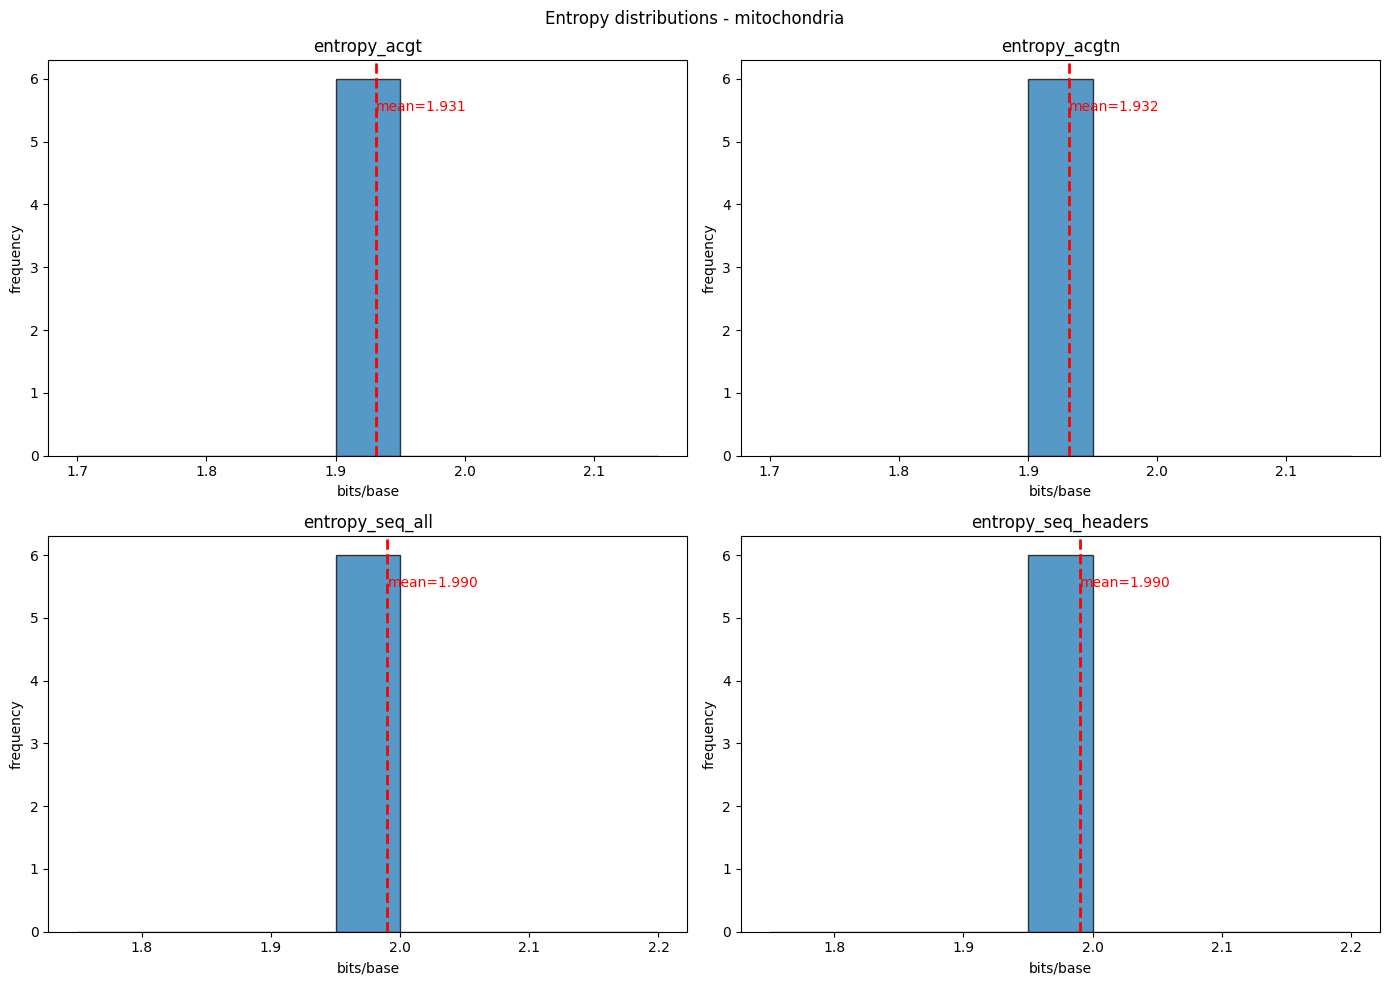

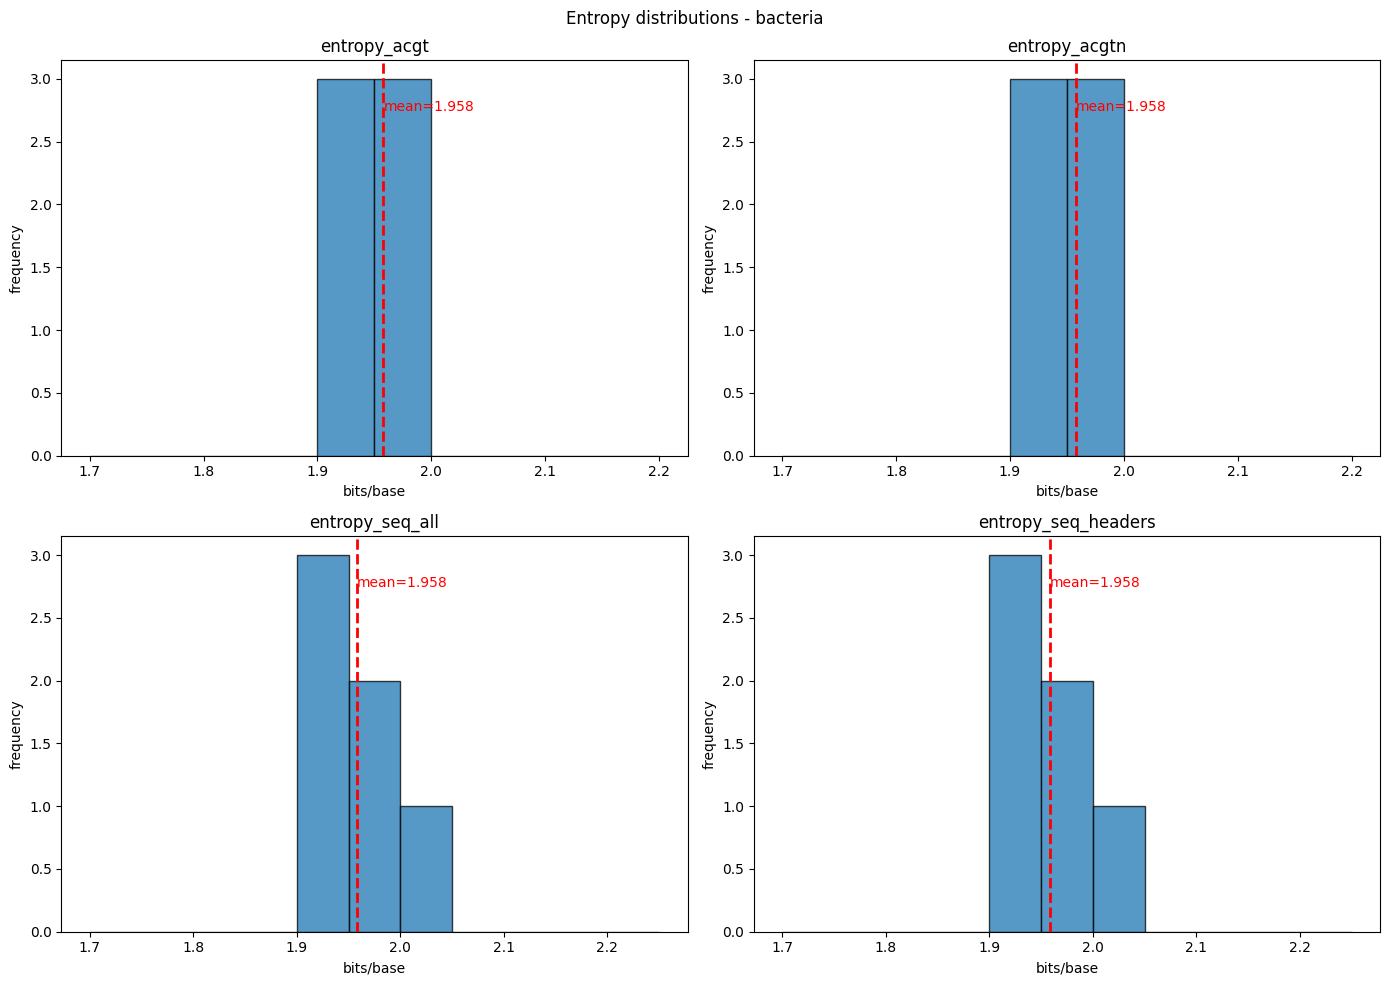

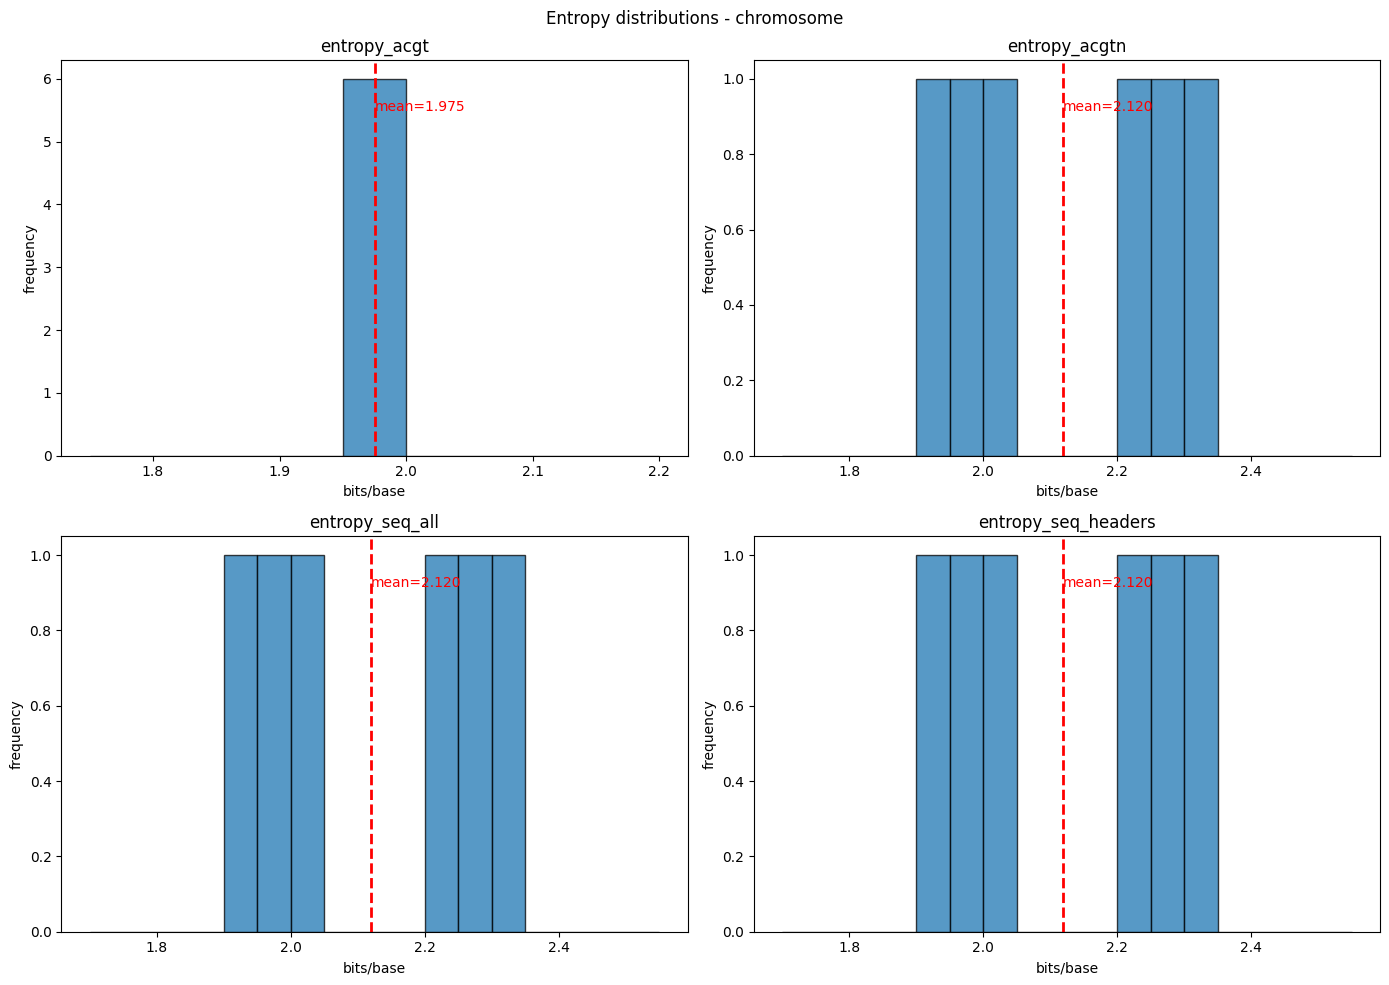

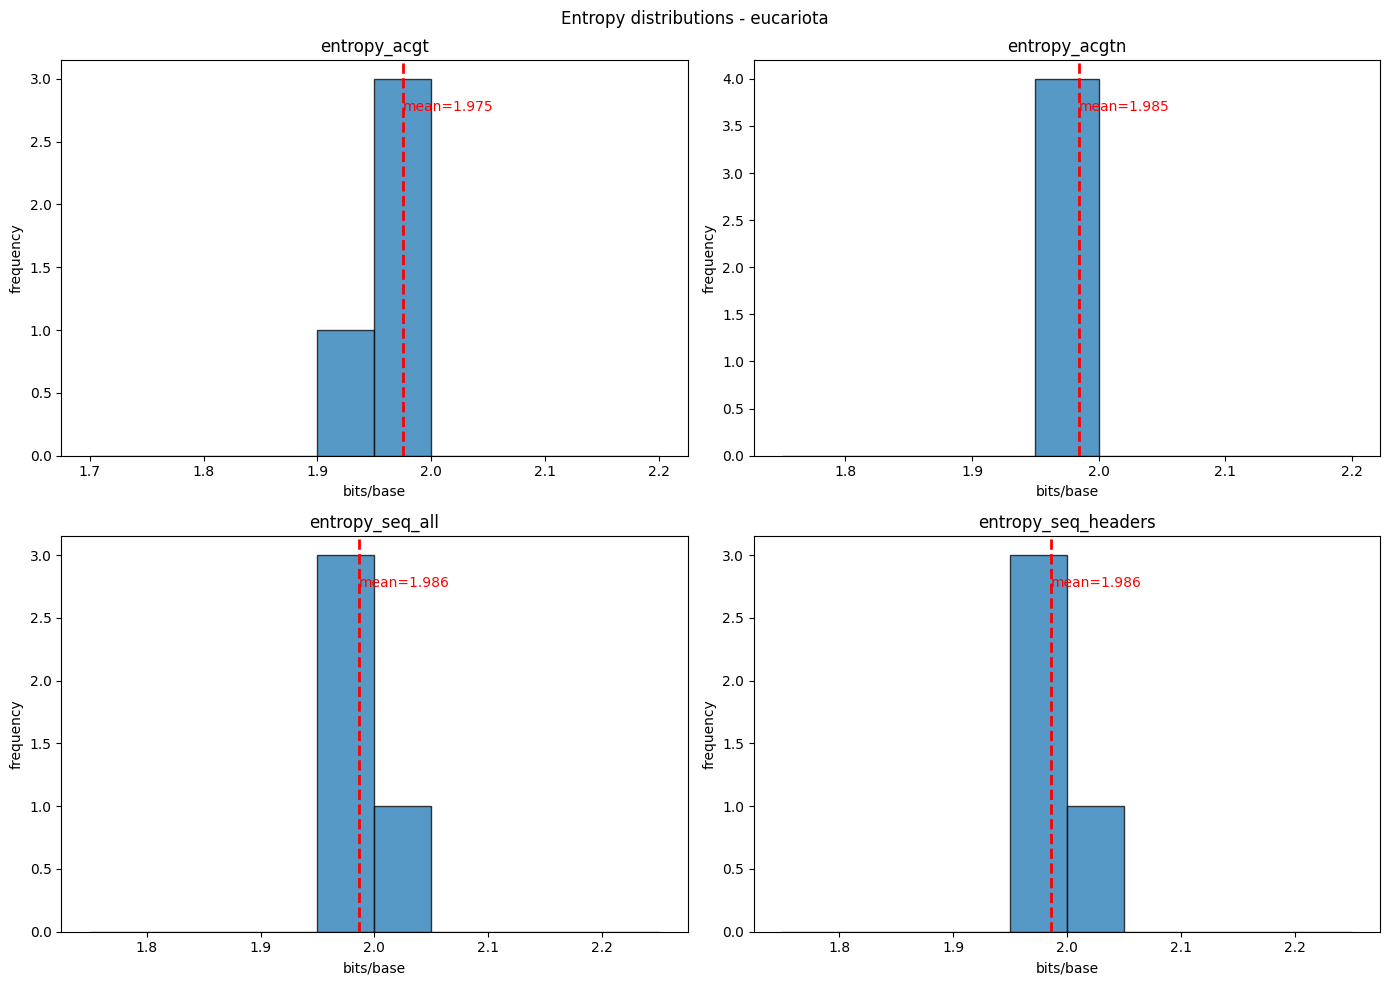

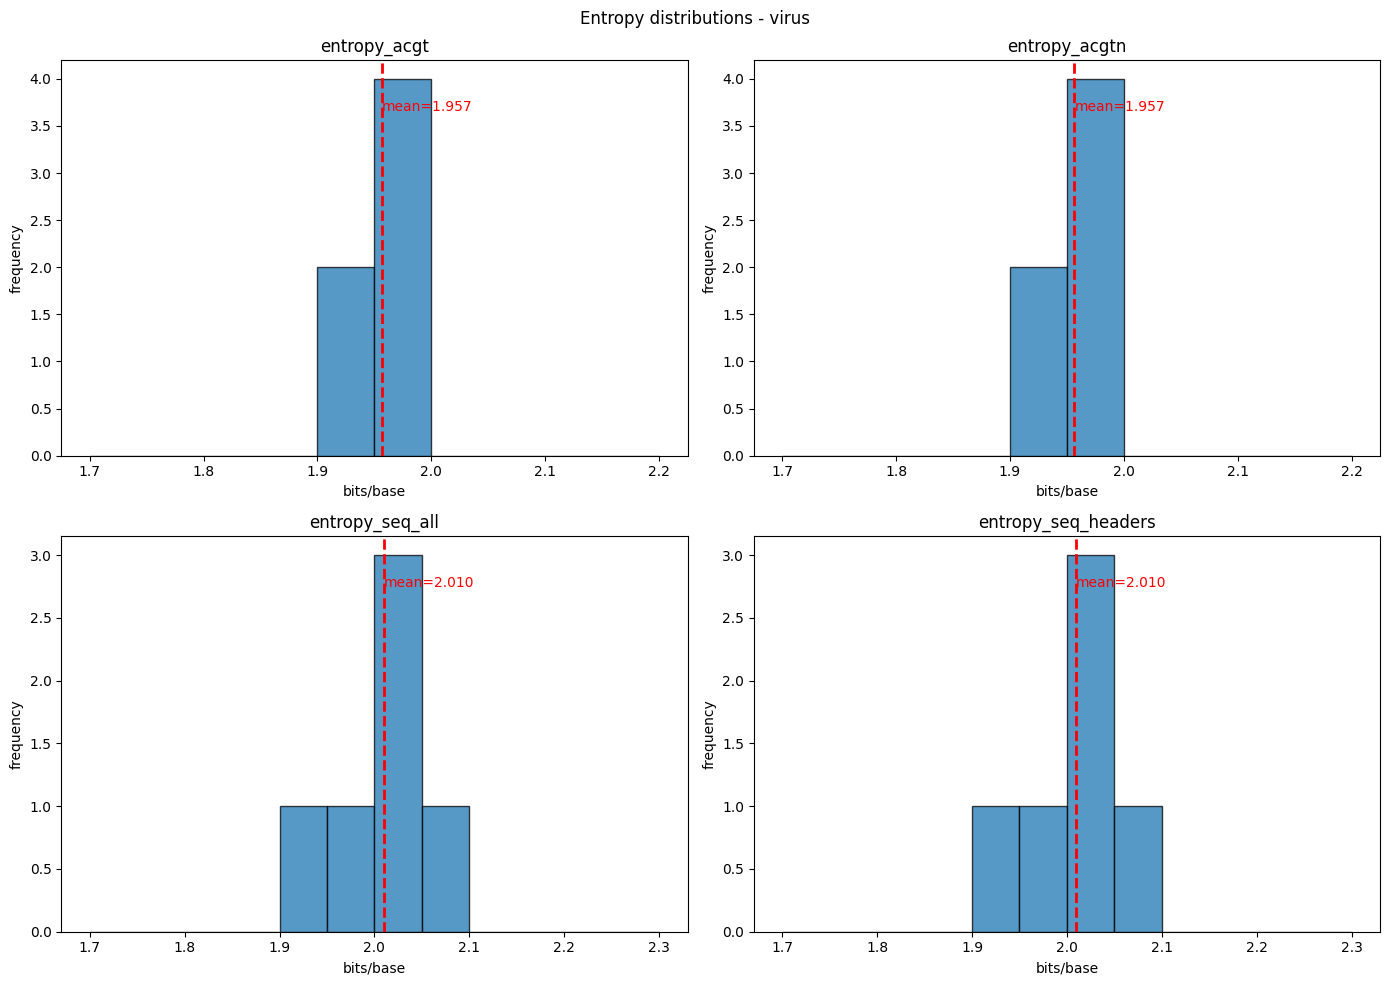

In [6]:
import matplotlib.pyplot as plt
import numpy as np

entropy_keys = [
    "entropy_acgt",
    "entropy_acgtn",
    "entropy_seq_all",
    "entropy_seq_headers"
]

for cat in categories:
    cat_datasets = {
        k: v for k, v in datasets.items()
        if v["category"] == cat
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, key in enumerate(entropy_keys):

        values = [
            v["entropies"][key]
            for v in cat_datasets.values()
            if v["entropies"][key] is not None
        ]

        if len(values) == 0:
            continue

        min_v = min(values) - 0.2
        max_v = max(values) + 0.2
        mean_val = np.mean(values)

        # marge petit perquè no quedi enganxat
        margin = (max_v - min_v) * 0.1 if max_v > min_v else 0.1

        # snap a graella
        bin_width = 0.05
        min_bin = np.floor(min_v / bin_width) * bin_width
        max_bin = np.ceil(max_v / bin_width) * bin_width

        bins = np.arange(min_bin, max_bin + bin_width, bin_width)

        axes[i].hist(values, bins=bins, edgecolor="black", alpha=0.75)
        axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=2)

        axes[i].text(
            mean_val,
            axes[i].get_ylim()[1] * 0.9,
            f"mean={mean_val:.3f}",
            color="red",
            va="top"
        )
        axes[i].set_title(key)
        axes[i].set_xlabel("bits/base")
        axes[i].set_ylabel("frequency")

    fig.suptitle(f"Entropy distributions - {cat}")
    plt.tight_layout()
    plt.show()

In [7]:
# proves per chromosome

for dataset_id, dataset_info in datasets.items():
    if dataset_info["category"] == "chromosome":
        
        print(f"{dataset_id}:")
        for key, value in dataset_info["entropies"].items():
            if key != "header_counts":
                print(f"  {key}: {value:.4f} bits/base")

        print(dataset_info["base_counts"])
        print(dataset_info["entropies"]["header_counts"])
        print()


homo_sapiens_chr1:
  entropy_acgt: 1.9801 bits/base
  entropy_acgtn: 2.2146 bits/base
  entropy_seq_all: 2.2147 bits/base
  entropy_seq_headers: 2.2147 bits/base
{'unknown': {'M': 1, 'R': 1}, 'A': 67070277, 'G': 48111528, 'N': 18475408, 'C': 48055043, 'T': 67244164}
{'A': 67070278, 'C': 48055045, 'G': 48111529, 'T': 67244164, 'N': 18475409, 'M': 1, 'R': 2, '>': 1, '_': 1, '0': 5, '1': 5, '.': 2, ' ': 7, 'H': 1, 'o': 5, 'm': 5, 's': 5, 'a': 2, 'p': 2, 'i': 2, 'e': 3, 'n': 1, 'c': 1, 'h': 2, 'r': 3, ',': 1, '3': 1, '8': 1, '4': 1, 'P': 1, 'y': 2, 'b': 1, 'l': 1}

homo_sapiens_chr21:
  entropy_acgt: 1.9762 bits/base
  entropy_acgtn: 2.2849 bits/base
  entropy_seq_all: 2.2849 bits/base
  entropy_seq_headers: 2.2849 bits/base
{'unknown': {'M': 2, 'R': 1}, 'A': 11820664, 'G': 8226381, 'N': 6621361, 'C': 8185244, 'T': 11856330}
{'A': 11820665, 'C': 8185246, 'G': 8226382, 'T': 11856330, 'N': 6621362, 'M': 2, 'R': 2, '>': 1, '_': 1, '0': 4, '2': 2, '1': 3, '.': 2, '9': 1, ' ': 7, 'H': 1, 'o': 5

In [8]:
accept = set("ACGTN")
total_unknown = dict()
total_known = dict()

for cat in categories:
    cat_datasets = {
        k: v for k, v in datasets.items()
        if v["category"] == cat
    }
    
    for dataset in cat_datasets.values():
        for k, v in dataset["base_counts"].get("unknown", {}).items():
            total_unknown[k] = total_unknown.get(k, 0) + v
    
        for i in accept:
            total_known[i] = total_known.get(i, 0) + dataset["base_counts"].get(i, 0)

print("Total unknown symbols across all datasets:")

total = sum(total_unknown.values()) + sum(total_known.values())
for k, v in total_unknown.items():
    print(f"{k}: {v:,} ({v/total:.4%})", end = "\t")
print("\n\nTotal known symbols across all datasets:")
for k, v in total_known.items():
    print(f"{k}: {v:,} ({v/total:.4%})", end = "\t")


Total unknown symbols across all datasets:
M: 79 (0.0000%)	R: 42 (0.0000%)	W: 127 (0.0000%)	Y: 88 (0.0000%)	S: 32 (0.0000%)	K: 53 (0.0000%)	

Total known symbols across all datasets:
T: 220,988,960 (27.0974%)	G: 152,530,952 (18.7031%)	A: 220,512,437 (27.0389%)	N: 69,341,536 (8.5026%)	C: 152,162,504 (18.6580%)	

In [9]:
accept = set("ACGTN")
total_unknown = dict()
total_known = dict()

for cat in categories:
    cat_datasets = {
        k: v for k, v in datasets.items()
        if v["category"] == cat
    }
    total_unknown[cat] = dict()
    total_known[cat] = dict()
    for dataset in cat_datasets.values():
        for k, v in dataset["base_counts"].get("unknown", {}).items():
            total_unknown[cat][k] = total_unknown[cat].get(k, 0) + v
    
        for i in accept:
            total_known[cat][i] = dataset["base_counts"].get(i, 0) + v

print("Total unknown symbols across all datasets:")

for cat in categories:
    print(f"{cat}:")
    total = sum(total_unknown[cat].values()) + sum(total_known[cat].values())
    for k, v in total_unknown[cat].items():
        print(f"{k}: {v} ({v/total:.4%})", end = "\t")
    print("\n") if total_unknown[cat] else None
    for k, v in total_known[cat].items():
        print(f"{k}: {v} ({v/total:.4%})", end = "\t")
    print("\n")

Total unknown symbols across all datasets:
chromosome:
M: 2 (0.0000%)	R: 5 (0.0000%)	W: 3 (0.0000%)	Y: 6 (0.0000%)	S: 2 (0.0000%)	

G: 5286895 (9.2384%)	N: 30812368 (53.8420%)	T: 7956169 (13.9027%)	C: 5285790 (9.2365%)	A: 7886193 (13.7804%)	

eucariota:
Y: 82 (0.0020%)	W: 124 (0.0030%)	M: 76 (0.0018%)	K: 53 (0.0013%)	S: 30 (0.0007%)	R: 36 (0.0009%)	

G: 1034332 (24.6321%)	N: 36 (0.0009%)	T: 1063687 (25.3312%)	C: 1037209 (24.7007%)	A: 1063450 (25.3256%)	

bacteria:
G: 461536 (16.3576%)	N: 37 (0.0013%)	T: 955351 (33.8592%)	C: 465868 (16.5111%)	A: 938749 (33.2708%)	

virus:
G: 5899 (19.6091%)	N: 36 (0.1197%)	T: 9630 (32.0114%)	C: 5528 (18.3758%)	A: 8990 (29.8840%)	

mitochondria:
G: 2205 (13.1650%)	N: 37 (0.2209%)	T: 4130 (24.6582%)	C: 5217 (31.1481%)	A: 5160 (30.8078%)	

